In [1]:
import nbimporter
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from torch import nn
from torch.optim import SGD
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from os.path import join
import torch
import numpy as np
from PIL import Image
from os import path

import python_file.dataclass as StreetSign
import python_file.function as Function
import python_file.network as Network

import matplotlib.pyplot as plt

from python_file.dirPath import csvDir, imageDir, Test, historiesDir, modelliDir, graphsDir

np.random.seed(1328)
torch.random.manual_seed(1328)

csv_files = [historiesDir / "minialexnetV2_dataset-200.csv",historiesDir / "minialexnet_dataset-200.csv",historiesDir / "lenet_dataset-200.csv"]
labels = ["MinialexnetV2", "Minialexnet", "Lenet"]
print(csv_files)
print(labels)

[PosixPath('train/histories/minialexnetV2_dataset-200.csv'), PosixPath('train/histories/minialexnet_dataset-200.csv'), PosixPath('train/histories/lenet_dataset-200.csv')]
['MinialexnetV2', 'Minialexnet', 'Lenet']


<h1>Accuracy Graphs</h1>

<h2>Confronto accuracy tra le 3 reti</h2>
In questa parte prenderemo e mostreremo in un primo grafico il confronto tra le 3 reti neurali AlexNet, MiniAlexNet e MiniAlexNetV2

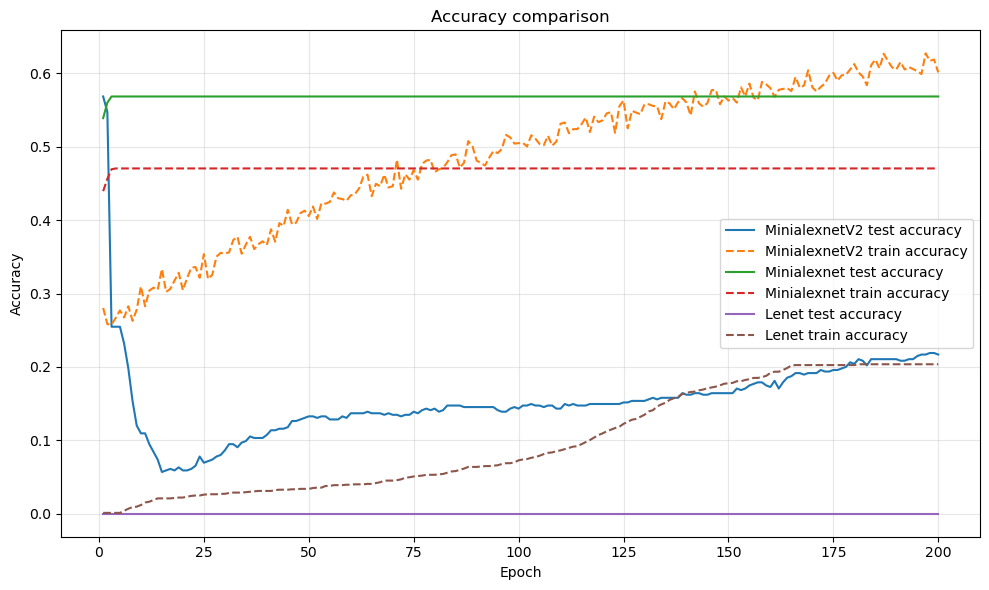

In [6]:
Function.plot_multiple_accuracy(csv_files, labels, graphsDir / "Confronto_Acc.png")

<h1>Loss Graphs</h1>

<h2>Confronto Loss tra le 3 reti</h2>
In questa parte prenderemo e mostreremo in un primo grafico il confronto tra le 3 reti neurali AlexNet, MiniAlexNet e MiniAlexNetV2

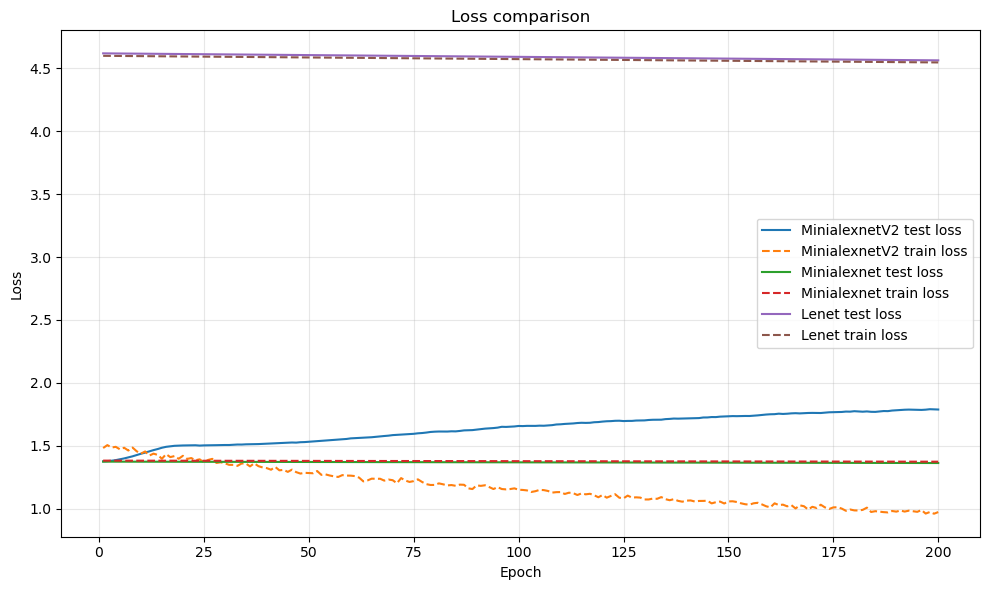

In [6]:
Function.plot_multiple_losses(csv_files, labels, graphsDir / "Confronto_Loss.png")

<h1>Stampa Tutti i grafici</h1>

In [2]:
#resize normale
tran = transforms.Compose([StreetSign.Rescale(32),StreetSign.RandomCrop(32),StreetSign.ToTensor()])

In [3]:
datatrain = StreetSign.StreetSignDataset(csvDir / 'classes.csv',imageDir,tran)
datatest = StreetSign.StreetSignTest( Test / 'prova.txt',Test,tran)

In [4]:
datatrain_loader = DataLoader(datatrain, batch_size=1024, shuffle=True)
datatest_loader = DataLoader(datatest, batch_size=1024, shuffle=True)

In [ ]:
epoche        = 200 
learning_rate = 0.001
momento       = 0.6

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.520
  Classe 1: 0.587
  Classe 2: 0.576

AUC macro (media): 0.561


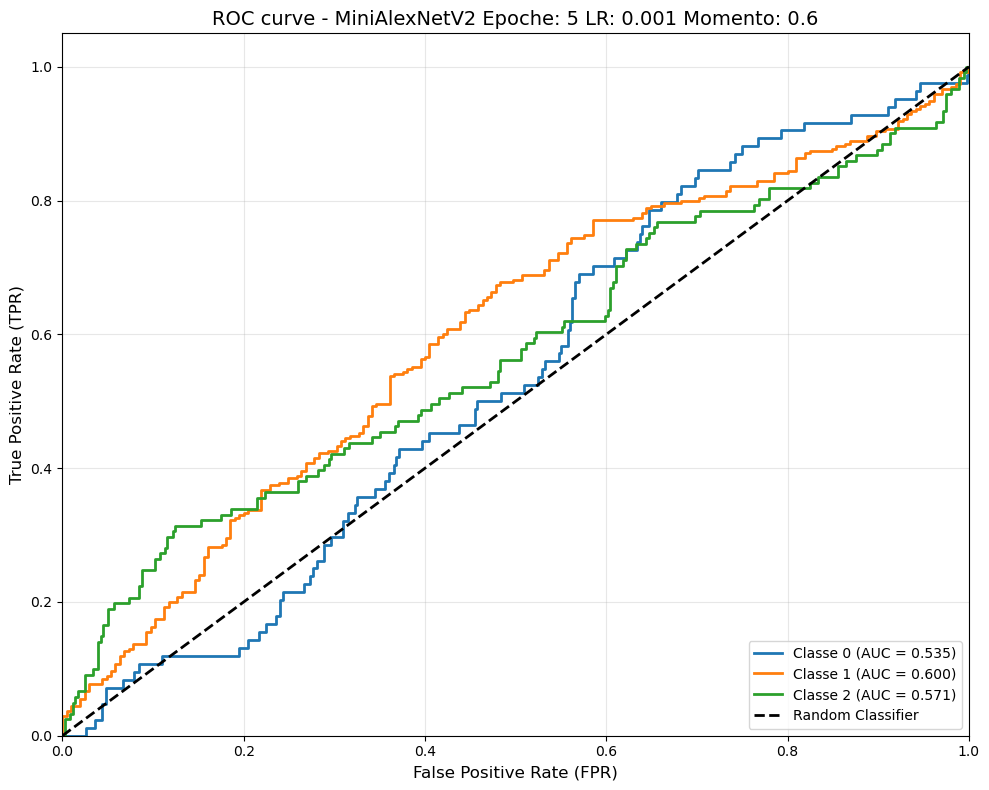

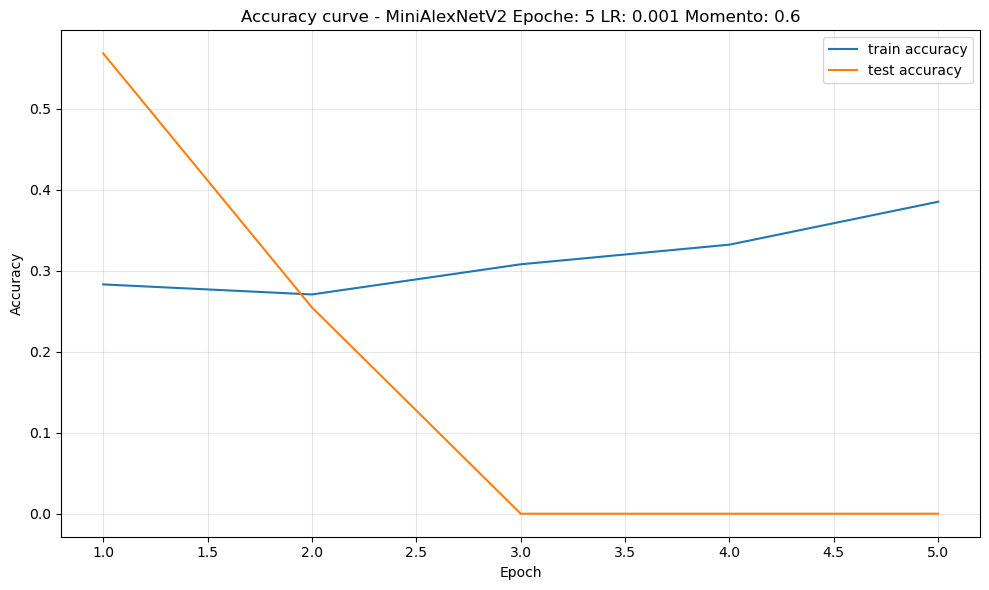

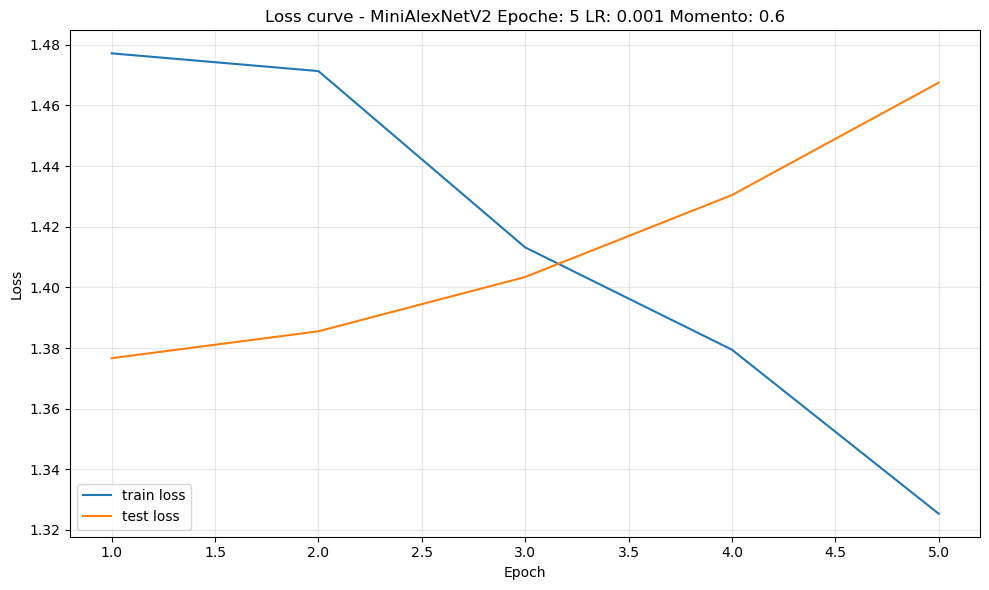

In [ ]:

exp_name='MiniAlexNetV2'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.MiniAlexNetV2()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.542
  Classe 1: 0.444
  Classe 2: 0.511

AUC macro (media): 0.499


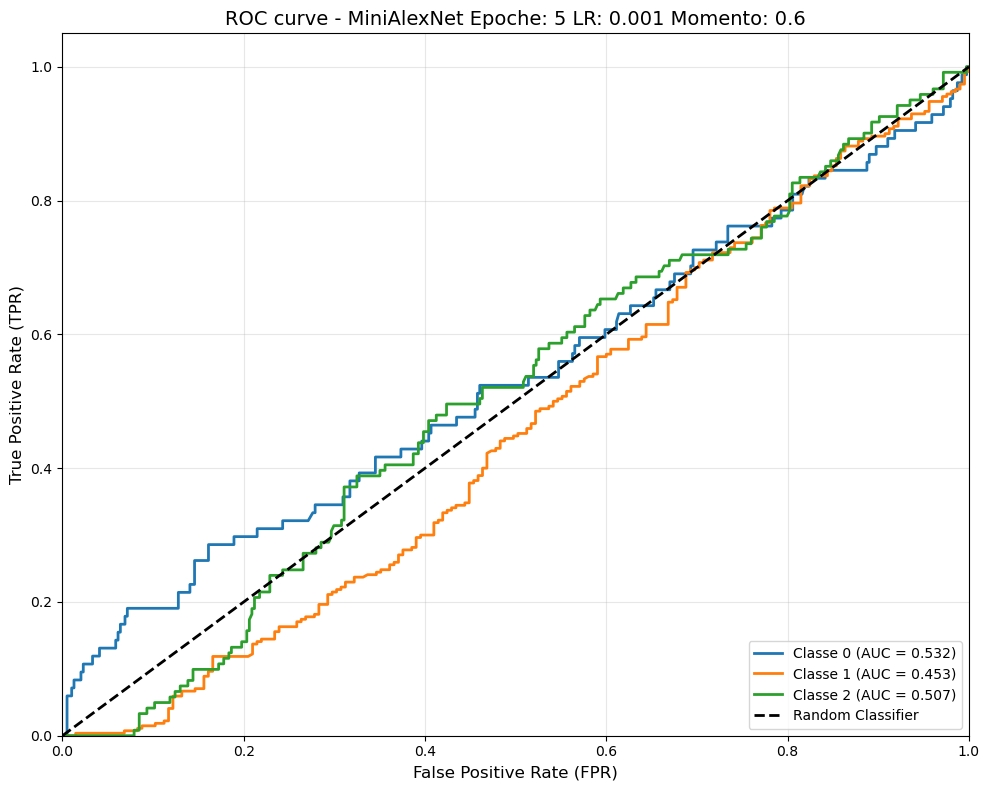

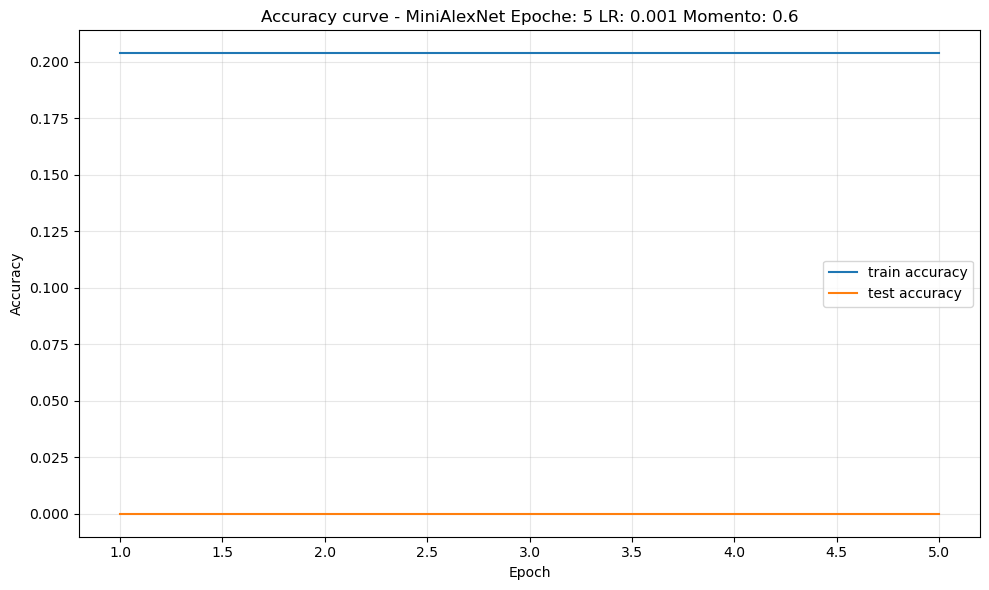

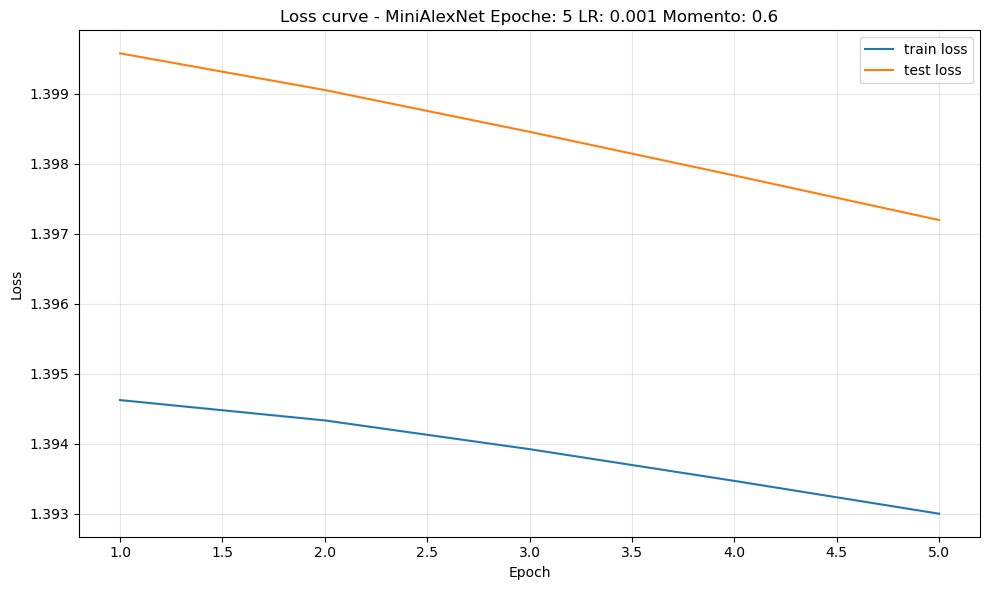

In [ ]:
exp_name='MiniAlexNet'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.MiniAlexNet()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.531
  Classe 1: 0.368
  Classe 2: 0.404

AUC macro (media): 0.434


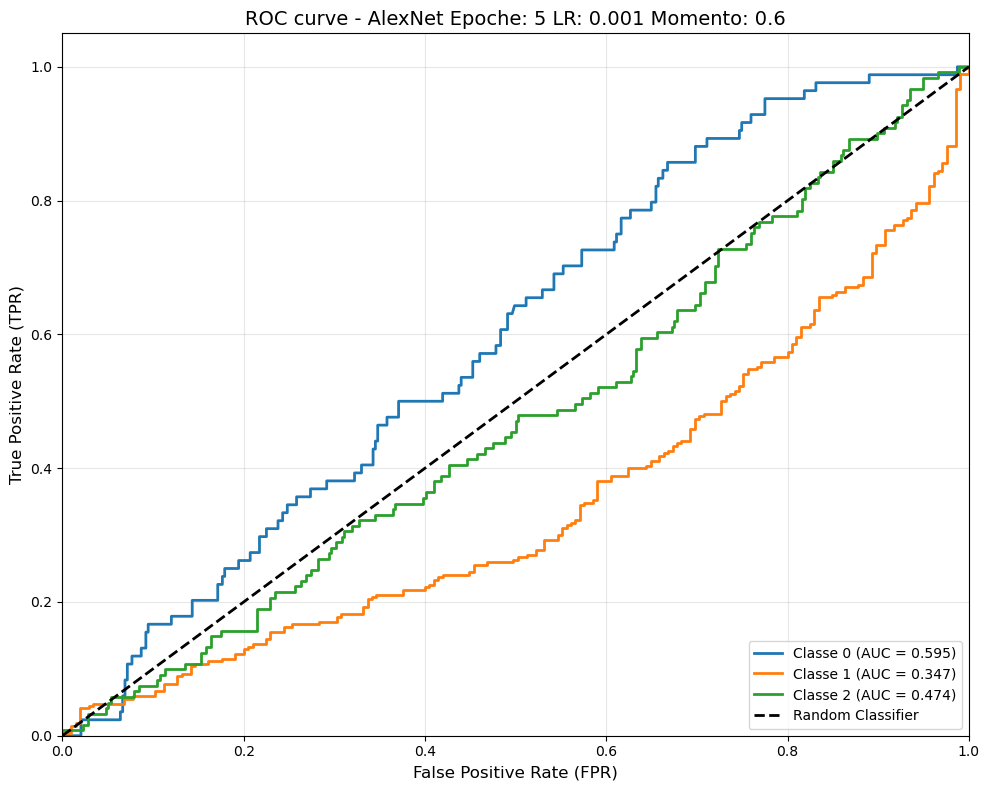

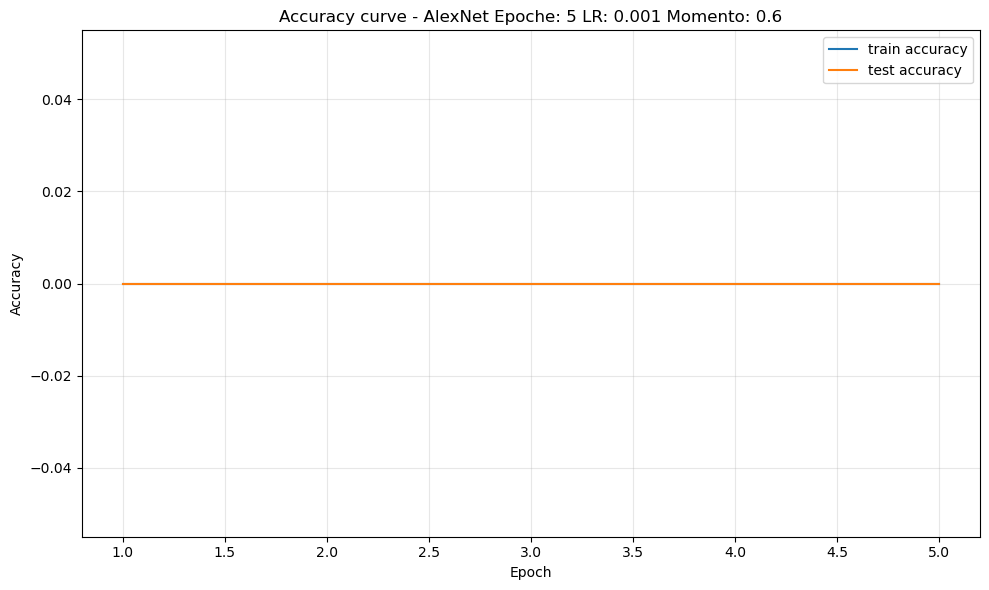

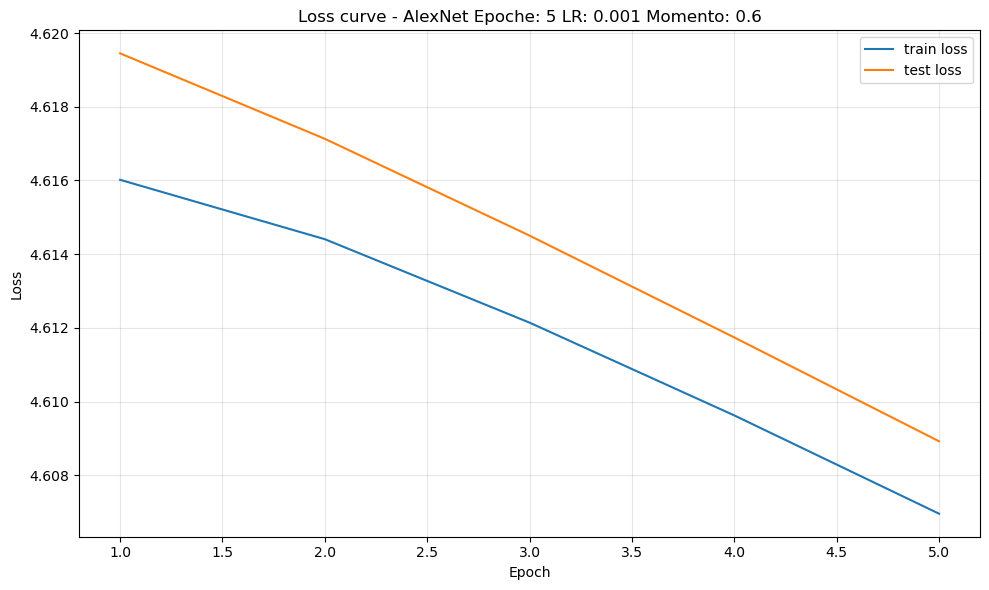

In [ ]:
exp_name='AlexNet'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.LeNetColor()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.520
  Classe 1: 0.587
  Classe 2: 0.576

AUC macro (media): 0.561


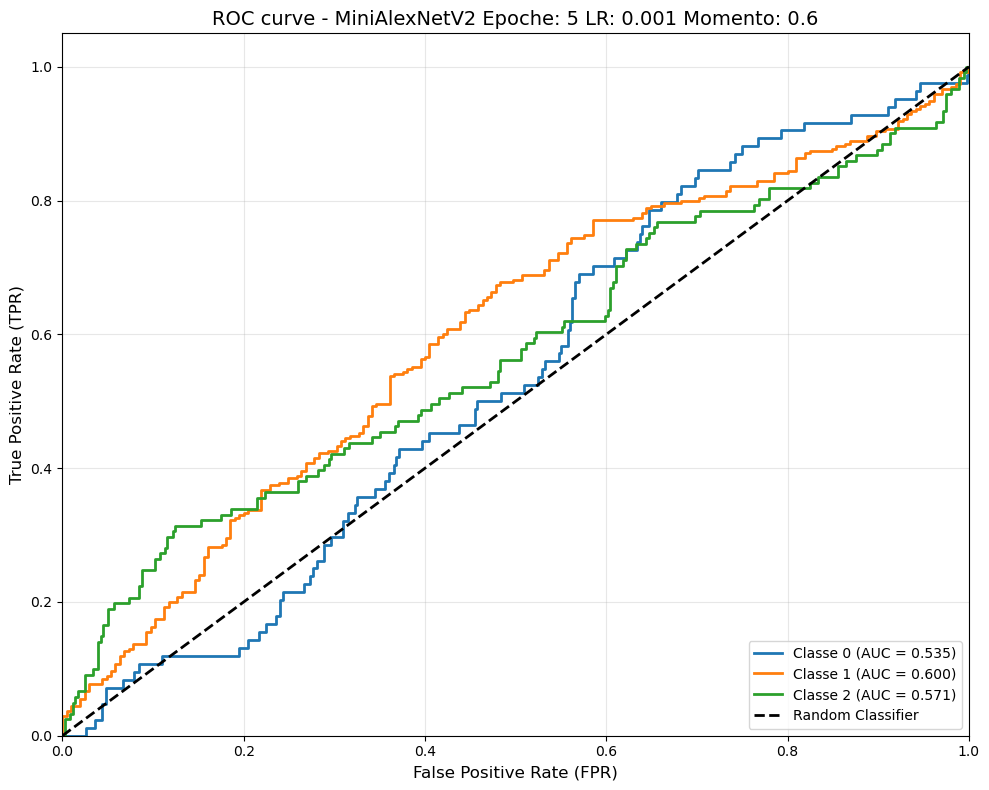

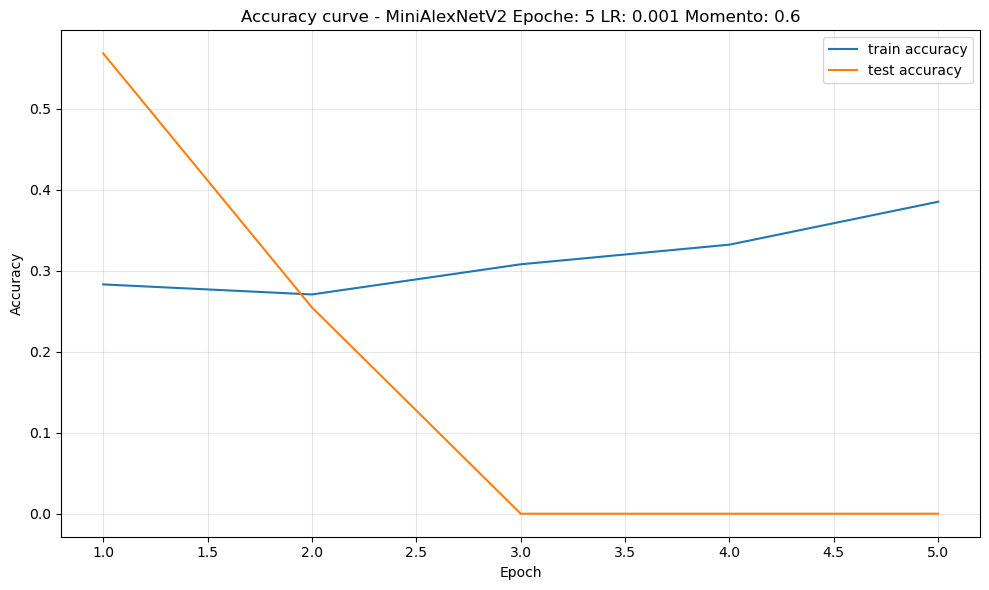

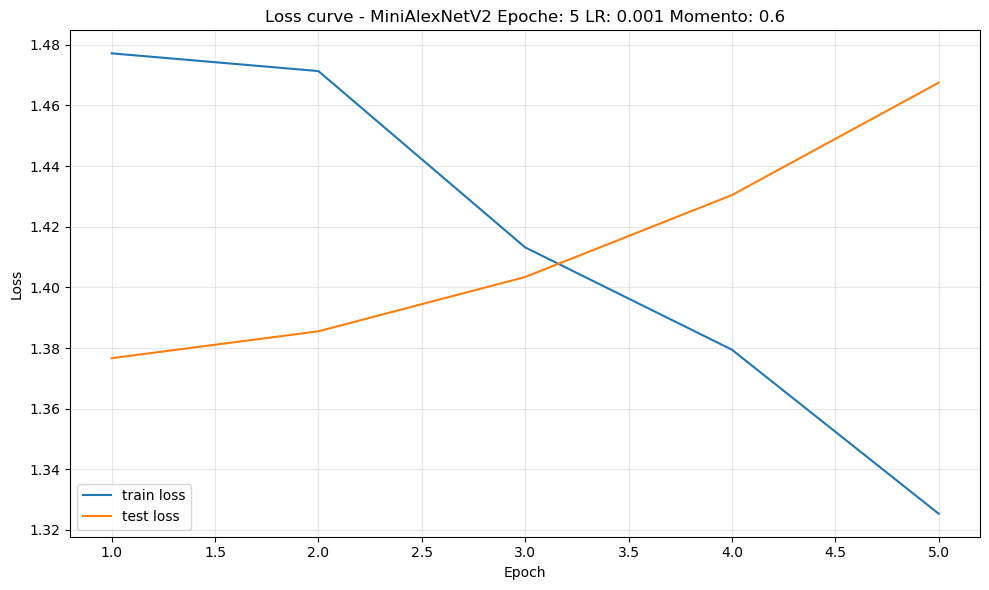

In [ ]:
exp_name='MiniAlexNetV2'

configs = [
    (0.0001, 0.3),
    (0.0001, 0.6),
    (0.0001, 0.9),
    (0.001, 0.3),
    (0.001, 0.6),
    (0.001, 0.9),
    (0.003, 0.3),
    (0.003, 0.6),
    (0.003, 0.9),
]

for lr, m in configs:
    learning_rate = lr
    momento = m

    file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
    titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
    titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
    titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
    outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
    outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
    outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
    model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = Network.MiniAlexNetV2()
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    probabilities, labels = Function.test_classifier(model, datatest_loader)

    Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
    Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
    Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)